In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [3]:
# Version de Keras
import keras

print(f"Versión de Keras: {keras.__version__}")

Versión de Keras: 3.13.2


In [4]:
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
class_names = ['Camiseta/top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

In [7]:
train_images.shape

(60000, 28, 28)

In [8]:
test_images.shape

(10000, 28, 28)

In [9]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

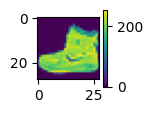

In [11]:
plt.figure(figsize=(1,1))
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

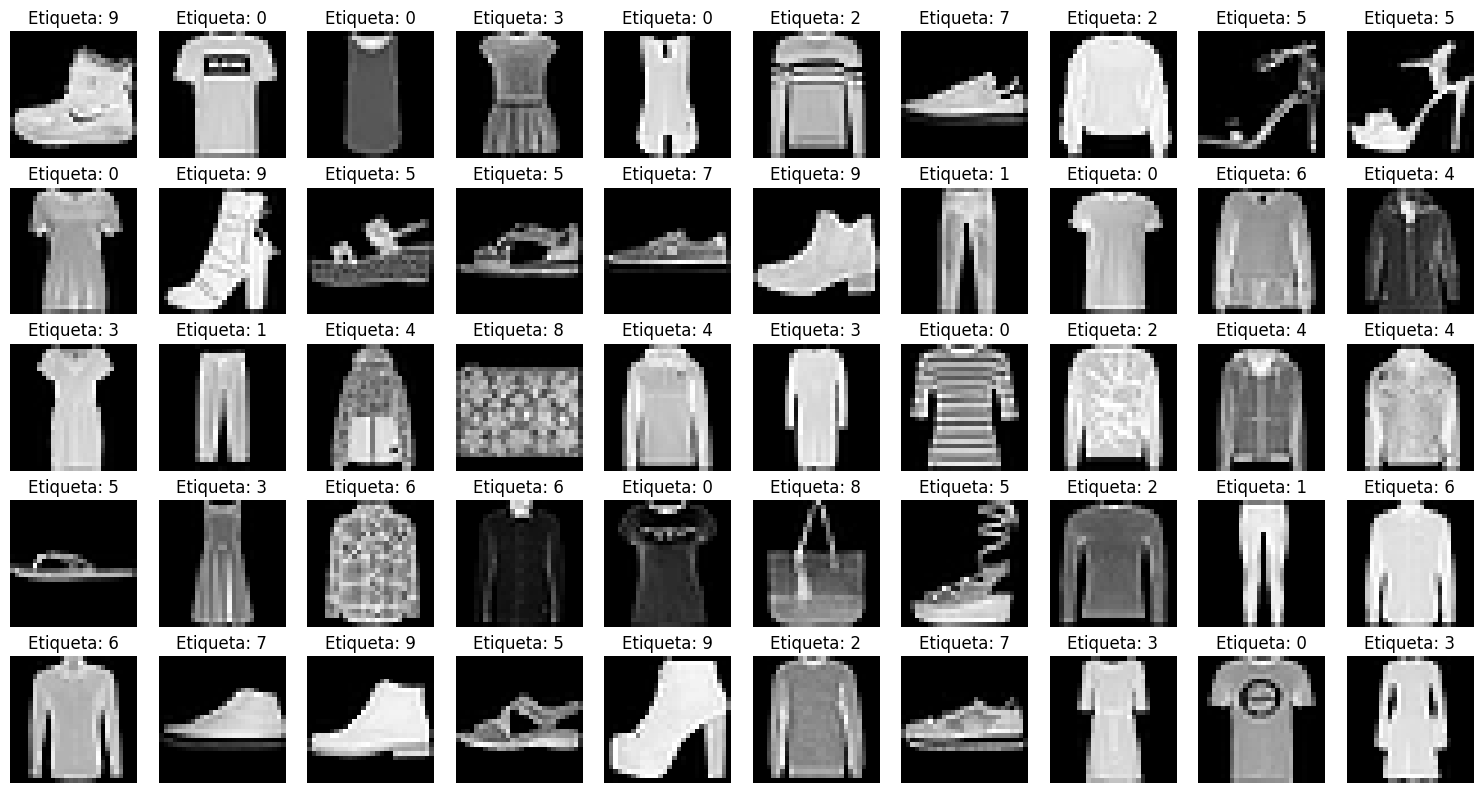

In [12]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for index, ax in enumerate(axes.flat):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(f"Etiqueta: {train_labels[index]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

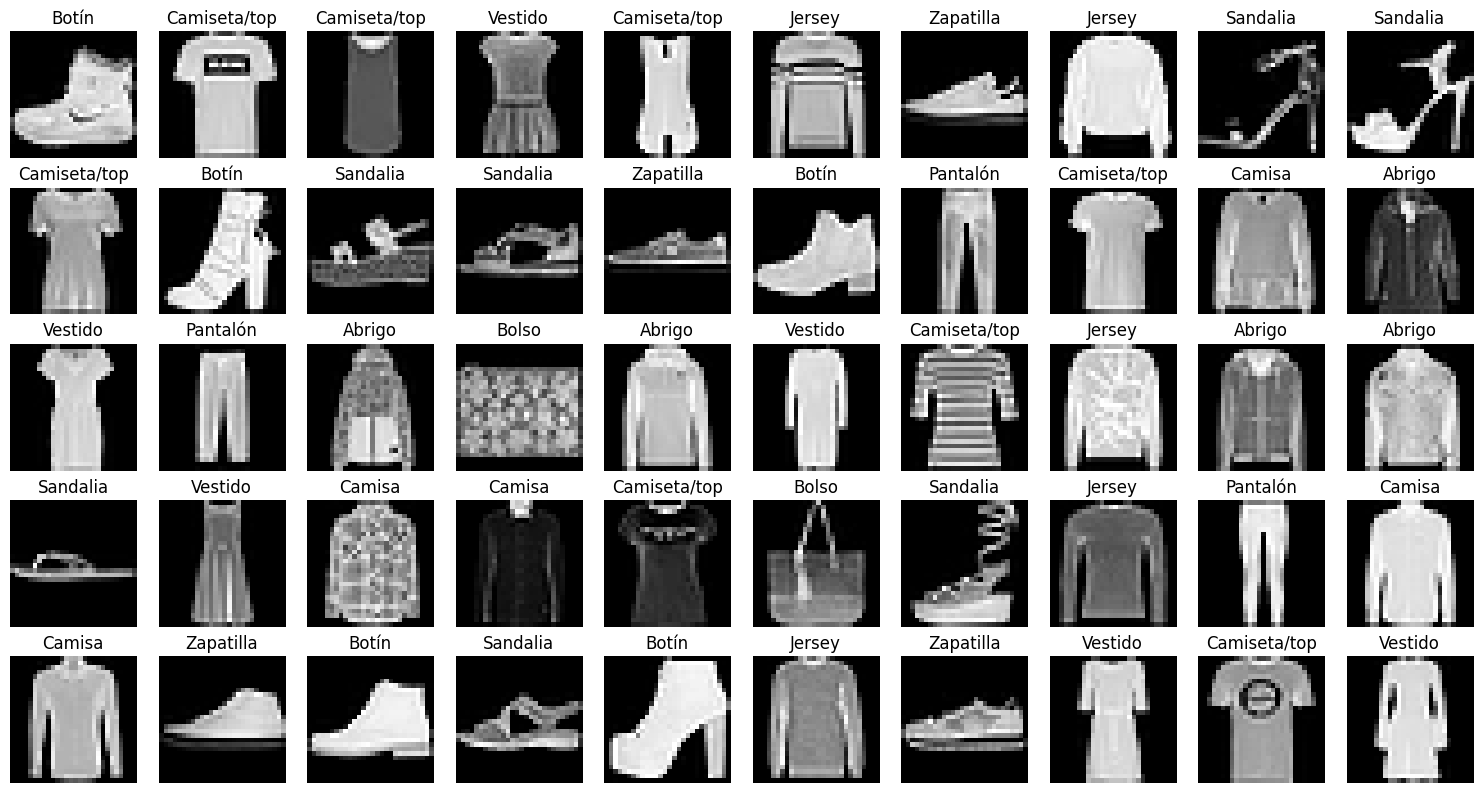

In [14]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for index, ax in enumerate(axes.flat):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(class_names[train_labels[index]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Forma C
# 1. Definir la entrada explícita
entradas = layers.Input(shape=(28, 28), name="Entrada")

# 2. Conectar cada capa pasando la variable anterior entre paréntesis
aplanada = layers.Flatten(name="Aplanar")(entradas)
capa_1 = layers.Dense(64, activation='relu', name="Oculta_1")(aplanada)
capa_2 = layers.Dropout(0.2, name="Dropout")(capa_1)
capa_3 = layers.Dense(32, activation='relu', name="Oculta_2")(capa_2)
capa_4 = layers.Dense(16, activation='relu', name="Oculta_3")(capa_3)
salida = layers.Dense(10, activation='softmax', name="Salida")(capa_4)

# 3. Encapsular definiendo explícitamente la entrada y la salida del modelo
model = models.Model(inputs=entradas, outputs=salida, name="Modelo_Funcional")

In [19]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4471 - loss: 2.2266
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5368 - loss: 1.1873
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5852 - loss: 1.1103
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6275 - loss: 0.9834
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6457 - loss: 0.9242
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6582 - loss: 0.8983
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6673 - loss: 0.8674
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6761 - loss: 0.8424
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6846 - loss: 0.8195
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6963 - loss: 0.7909


In [23]:
# Guarda el modelo en la carpeta específica de mi Drive
from google.colab import auth, drive
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# Montar Drive y autenticar el acceso a la API
drive.mount('/content/drive')
auth.authenticate_user()

servicio_drive = build('drive', 'v3')
id_carpeta = '12ogucOuxdnzIesAWtxrdKZxahgWmEFol'
ruta_temporal = '/content/fashion_model_entrenado.keras'

# Guardar temporalmente el modelo en Colab
model.save(ruta_temporal)

# Subirlo directamente dentro de la carpeta indicada por su ID
metadatos = {
    'name': 'fashion_model_entrenado.keras',
    'parents': [id_carpeta]
}
archivo = MediaFileUpload(ruta_temporal, mimetype='application/octet-stream')
modelo_drive = servicio_drive.files().create(
    body=metadatos,
    media_body=archivo,
    fields='id, name, webViewLink'
).execute()

print(f"Modelo guardado en la carpeta de Drive: {modelo_drive['name']}")
print(f"Enlace: {modelo_drive['webViewLink']}")

Modelo guardado en la carpeta de Drive: fashion_model_entrenado.keras
Enlace: https://drive.google.com/file/d/1LNY8UMz_v1ZOLwNg5S2cYGAnwq6n4zBo/view?usp=drivesdk


In [24]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 2s - 6ms/step - accuracy: 0.7438 - loss: 0.6647

Test accuracy: 0.7437999844551086


In [26]:
predictions[0]

array([5.77198678e-10, 1.31055666e-09, 3.98413569e-23, 1.43554635e-08,
       7.24610547e-17, 1.23776846e-01, 9.41545290e-14, 1.50247708e-01,
       1.43674297e-05, 7.25961089e-01], dtype=float32)

In [27]:
posicion= np.argmax(predictions[0])

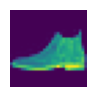

In [28]:
plt.figure(figsize=(1, 1))
plt.imshow(test_images[0])
plt.axis('off')
plt.show()

In [29]:
predicted_class = class_names[posicion]
print("La predicción para la primera imagen de prueba es:", predicted_class)

La predicción para la primera imagen de prueba es: Botín
